In [10]:
import os
import time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import cupy as cp
import cudf
from cuml.manifold import TSNE
import matplotlib.pyplot as plt


In [3]:
data = pd.read_csv("../../../data/resample_minmax_all.csv")

# We keep "apogee_id" aside (if needed)
data_id = data["apogee_id"]

# Let's extract the target columns: TEFF, LOGG, J, H, K
# (All assumed to be normalized [0,1] or something similar)
data_target = data[["TEFF", "LOGG", "J", "H", "K"]]

# We drop them from 'data' to keep only the chemical features (X)
columns_to_drop = ["apogee_id", "TEFF", "LOGG", "J", "H", "K"]
data = data.drop(columns=columns_to_drop)

print("✅ Data Loaded and Preprocessed Successfully!")
print(f"🆔 ID Columns: {data_id.shape}")
print(f"🎯 Target Columns: {data_target.shape}")
print("Columns used as input features:", data.columns)

# Convert to float32
data = data.astype('float32').reset_index(drop=True)
data_target = data_target.astype('float32').reset_index(drop=True)

# Convert to torch tensors
X_full = torch.tensor(data.values, dtype=torch.float32)
y_teff  = torch.tensor(data_target["TEFF"].values, dtype=torch.float32)
y_logg  = torch.tensor(data_target["LOGG"].values, dtype=torch.float32)
y_j     = torch.tensor(data_target["J"].values,    dtype=torch.float32)
y_h     = torch.tensor(data_target["H"].values,    dtype=torch.float32)
y_k     = torch.tensor(data_target["K"].values,    dtype=torch.float32)

N = len(data)
print("Final X shape:", X_full.shape)
print("Targets TEFF shape:", y_teff.shape)
print("Targets LOGG shape:", y_logg.shape)
print("Targets J shape:", y_j.shape)
print("Targets H shape:", y_h.shape)
print("Targets K shape:", y_k.shape)

# ---------------------------------------------------
# Train/test split (90% / 10%)
indices = np.arange(N)

# Ajout de la seed pour la reproductibilité
np.random.seed(42)
np.random.shuffle(indices)

split_idx = int(0.9 * N)
train_idx = indices[:split_idx]
test_idx  = indices[split_idx:]

X_train = X_full[train_idx]
X_test  = X_full[test_idx]

y_teff_train = y_teff[train_idx]
y_logg_train = y_logg[train_idx]
y_j_train    = y_j[train_idx]
y_h_train    = y_h[train_idx]
y_k_train    = y_k[train_idx]

y_teff_test = y_teff[test_idx]
y_logg_test = y_logg[test_idx]
y_j_test    = y_j[test_idx]
y_h_test    = y_h[test_idx]
y_k_test    = y_k[test_idx]

print("\nSplit done!")
print(f"Train set size: {len(train_idx)}")
print(f"Test set size : {len(test_idx)}")


✅ Data Loaded and Preprocessed Successfully!
🆔 ID Columns: (175770,)
🎯 Target Columns: (175770, 5)
Columns used as input features: Index(['C_FE', 'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE',
       'S_FE', 'K_FE', 'CA_FE', 'TI_FE', 'V_FE', 'CR_FE', 'MN_FE', 'NI_FE',
       'FE_H'],
      dtype='object')
Final X shape: torch.Size([175770, 17])
Targets TEFF shape: torch.Size([175770])
Targets LOGG shape: torch.Size([175770])
Targets J shape: torch.Size([175770])
Targets H shape: torch.Size([175770])
Targets K shape: torch.Size([175770])

Split done!
Train set size: 158193
Test set size : 17577


In [4]:
class SiamesePairsDataset(Dataset):
    """
    This dataset generates pairs of stars (x_i, x_j) along with
    their targets (teff_i, logg_i, j_i, h_i, k_i, etc.), and
    a similarity label (1 or 0) based on the Euclidean distance
    in the 5D space (TEFF, LOGG, J, H, K).
    """
    def __init__(self, X, teff, logg, jvals, hvals, kvals, threshold=0.3):
        """
        X: Torch tensor [N, D] for the chemical features
        teff, logg, jvals, hvals, kvals: Torch tensors [N] (normalized [0,1] presumably)
        threshold: float, distance threshold for deciding 'similar' (label=1)
        """
        super().__init__()
        self.X = X
        self.teff = teff
        self.logg = logg
        self.jvals = jvals
        self.hvals = hvals
        self.kvals = kvals
        self.N = X.shape[0]
        self.threshold = threshold

    def __len__(self):
        # We'll define the dataset size as 2*N or something similar
        # so that each epoch covers about 2*N pairs
        return self.N * 2

    def __getitem__(self, idx):
        # Random anchor
        i = np.random.randint(0, self.N)
        x_i = self.X[i]
        teff_i = self.teff[i]
        logg_i = self.logg[i]
        j_i    = self.jvals[i]
        h_i    = self.hvals[i]
        k_i    = self.kvals[i]

        # Random choice: similar or different
        is_similar = (np.random.rand() < 0.5)

        # We will find a j that matches or differs
        j = np.random.randint(0, self.N)

        teff_j = self.teff[j]
        logg_j = self.logg[j]
        j_j    = self.jvals[j]
        h_j    = self.hvals[j]
        k_j    = self.kvals[j]

        # Physical distance in TEFF,LOGG,J,H,K
        d_teff = float(abs(teff_i - teff_j))
        d_logg = float(abs(logg_i - logg_j))
        d_j    = float(abs(j_i - j_j))
        d_h    = float(abs(h_i - h_j))
        d_k    = float(abs(k_i - k_j))
        d_phys = np.sqrt(d_teff**2 + d_logg**2 + d_j**2 + d_h**2 + d_k**2)

        if is_similar:
            while d_phys >= self.threshold:
                j = np.random.randint(0, self.N)
                teff_j = self.teff[j]
                logg_j = self.logg[j]
                j_j    = self.jvals[j]
                h_j    = self.hvals[j]
                k_j    = self.kvals[j]
                d_teff = float(abs(teff_i - teff_j))
                d_logg = float(abs(logg_i - logg_j))
                d_j    = float(abs(j_i - j_j))
                d_h    = float(abs(h_i - h_j))
                d_k    = float(abs(k_i - k_j))
                d_phys = np.sqrt(d_teff**2 + d_logg**2 + d_j**2 + d_h**2 + d_k**2)
            label = 1.0
        else:
            while d_phys < self.threshold:
                j = np.random.randint(0, self.N)
                teff_j = self.teff[j]
                logg_j = self.logg[j]
                j_j    = self.jvals[j]
                h_j    = self.hvals[j]
                k_j    = self.kvals[j]
                d_teff = float(abs(teff_i - teff_j))
                d_logg = float(abs(logg_i - logg_j))
                d_j    = float(abs(j_i - j_j))
                d_h    = float(abs(h_i - h_j))
                d_k    = float(abs(k_i - k_j))
                d_phys = np.sqrt(d_teff**2 + d_logg**2 + d_j**2 + d_h**2 + d_k**2)
            label = 0.0

        x_j = self.X[j]

        return (x_i, x_j,
                teff_i, logg_i, j_i, h_i, k_i,
                teff_j, logg_j, j_j, h_j, k_j,
                torch.tensor(label, dtype=torch.float32))


In [5]:
class EmbeddingNet(nn.Module):
    def __init__(self, input_dim, embedding_dim=4):
        super(EmbeddingNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, embedding_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.leaky_relu(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.leaky_relu(x)
        z = self.fc3(x)
        return z

class SiameseMultiTaskNetwork(nn.Module):
    def __init__(self, input_dim, embedding_dim=4):
        super(SiameseMultiTaskNetwork, self).__init__()
        self.embedding_net = EmbeddingNet(input_dim, embedding_dim)
        # Regressor: 5 outputs -> TEFF, LOGG, J, H, K
        self.regressor = nn.Linear(embedding_dim, 5)

    def forward_once(self, x):
        z = self.embedding_net(x)
        out_reg = self.regressor(z)  # shape [batch_size, 5]
        return z, out_reg

    def forward(self, x1, x2):
        z1, out1 = self.forward_once(x1)
        z2, out2 = self.forward_once(x2)
        return (z1, out1), (z2, out2)


In [6]:
def contrastive_loss(z1, z2, label, margin=1.0):
    # label = 1 -> similar, 0 -> dissimilar
    dist = F.pairwise_distance(z1, z2, p=2)
    loss_pos = label * (dist ** 2)
    loss_neg = (1 - label) * F.relu(margin - dist) ** 2
    loss = loss_pos + loss_neg
    return loss.mean()

def multitask_loss(z1, z2, label_sim,
                   out1, y1,
                   out2, y2,
                   alpha_contrast=1.0,
                   alpha_mse=1.0,
                   margin=1.0):
    """
    out1, out2 -> [batch_size, 5] = TEFF_pred, LOGG_pred, J_pred, H_pred, K_pred
    y1, y2     -> [batch_size, 5] = TEFF_true, LOGG_true, J_true, H_true, K_true
    """
    # 1) Contrastive
    c_loss = contrastive_loss(z1, z2, label_sim, margin=margin)

    # 2) MSE for each star
    # we can do a simple mean over all 5 outputs
    mse1 = F.mse_loss(out1, y1)
    mse2 = F.mse_loss(out2, y2)
    total_mse = (mse1 + mse2) / 2.0

    # Combine
    total_loss = alpha_contrast * c_loss + alpha_mse * total_mse
    return total_loss, c_loss.item(), total_mse.item()


In [18]:
# Let's create the train dataset / train loader
train_dataset = SiamesePairsDataset(X_train,
                                    y_teff_train, y_logg_train,
                                    y_j_train, y_h_train, y_k_train,
                                    threshold=0.3)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

# Build the model
model = SiameseMultiTaskNetwork(input_dim=X_train.shape[1], embedding_dim=2).cuda()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 5
alpha_contrast = 1.0
alpha_mse = 1.0
margin = 1.0

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    print(f"\n=== EPOCH {epoch+1}/{n_epochs} ===")
    print(f"  Number of batches: {len(train_loader)}")

    start_time = time.time()

    for batch_idx, batch in enumerate(train_loader):
        # batch = x_i, x_j, teff_i, logg_i, j_i, h_i, k_i, teff_j, logg_j, j_j, h_j, k_j, label
        (x_i, x_j,
         teff_i, logg_i, j_i, h_i, k_i,
         teff_j, logg_j, j_j, h_j, k_j,
         label_sim) = batch

        # Move to GPU
        x_i = x_i.cuda()
        x_j = x_j.cuda()
        teff_i = teff_i.cuda()
        logg_i = logg_i.cuda()
        j_i = j_i.cuda()
        h_i = h_i.cuda()
        k_i = k_i.cuda()

        teff_j = teff_j.cuda()
        logg_j = logg_j.cuda()
        j_j = j_j.cuda()
        h_j = h_j.cuda()
        k_j = k_j.cuda()

        label_sim = label_sim.cuda()

        # Forward
        (z1, out1), (z2, out2) = model(x_i, x_j)
        # out1, out2: shape [bs, 5]
        # We build the ground truth for star i and star j
        y1 = torch.stack([teff_i, logg_i, j_i, h_i, k_i], dim=1)  # shape [bs, 5]
        y2 = torch.stack([teff_j, logg_j, j_j, h_j, k_j], dim=1)  # shape [bs, 5]

        # Loss
        loss, c_loss_val, mse_val = multitask_loss(
            z1, z2, label_sim,
            out1, y1,
            out2, y2,
            alpha_contrast=alpha_contrast,
            alpha_mse=alpha_mse,
            margin=margin
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f"    [Batch {batch_idx+1}/{len(train_loader)}] "
                  f"Loss={loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)
    elapsed = time.time() - start_time
    print(f"-> End of Epoch {epoch+1}, Loss={epoch_loss:.4f}, Time={elapsed:.1f}s")



=== EPOCH 1/5 ===
  Number of batches: 618
    [Batch 100/618] Loss=0.3104
    [Batch 200/618] Loss=0.2504
    [Batch 300/618] Loss=0.2599
    [Batch 400/618] Loss=0.2357
    [Batch 500/618] Loss=0.2308
    [Batch 600/618] Loss=0.2391
-> End of Epoch 1, Loss=0.2696, Time=72.4s

=== EPOCH 2/5 ===
  Number of batches: 618
    [Batch 100/618] Loss=0.2348
    [Batch 200/618] Loss=0.2251
    [Batch 300/618] Loss=0.2268
    [Batch 400/618] Loss=0.2222
    [Batch 500/618] Loss=0.2386
    [Batch 600/618] Loss=0.2439
-> End of Epoch 2, Loss=0.2337, Time=71.6s

=== EPOCH 3/5 ===
  Number of batches: 618
    [Batch 100/618] Loss=0.2250
    [Batch 200/618] Loss=0.2200
    [Batch 300/618] Loss=0.2109
    [Batch 400/618] Loss=0.2195
    [Batch 500/618] Loss=0.2185
    [Batch 600/618] Loss=0.2290
-> End of Epoch 3, Loss=0.2269, Time=71.6s

=== EPOCH 4/5 ===
  Number of batches: 618
    [Batch 100/618] Loss=0.2281
    [Batch 200/618] Loss=0.2332
    [Batch 300/618] Loss=0.2256
    [Batch 400/618] Los

In [19]:
model.eval()

test_dataset = SiamesePairsDataset(X_test,
                                   y_teff_test, y_logg_test,
                                   y_j_test, y_h_test, y_k_test,
                                   threshold=0.3)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

test_loss = 0.0
with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        (x_i, x_j,
         teff_i, logg_i, j_i, h_i, k_i,
         teff_j, logg_j, j_j, h_j, k_j,
         label_sim) = batch

        x_i = x_i.cuda()
        x_j = x_j.cuda()
        teff_i = teff_i.cuda()
        logg_i = logg_i.cuda()
        j_i = j_i.cuda()
        h_i = h_i.cuda()
        k_i = k_i.cuda()

        teff_j = teff_j.cuda()
        logg_j = logg_j.cuda()
        j_j = j_j.cuda()
        h_j = h_j.cuda()
        k_j = k_j.cuda()

        label_sim = label_sim.cuda()

        (z1, out1), (z2, out2) = model(x_i, x_j)
        y1 = torch.stack([teff_i, logg_i, j_i, h_i, k_i], dim=1)
        y2 = torch.stack([teff_j, logg_j, j_j, h_j, k_j], dim=1)

        loss, c_loss_val, mse_val = multitask_loss(
            z1, z2, label_sim,
            out1, y1,
            out2, y2,
            alpha_contrast=alpha_contrast,
            alpha_mse=alpha_mse,
            margin=margin
        )
        test_loss += loss.item()

test_loss /= len(test_loader)
print(f"\nTest Loss = {test_loss:.4f} (on {len(test_loader)} batches)")


torch.save(model.state_dict(), "output_weight/siamese_multitask_model_jhk_teff_logg_2D.pth")



Test Loss = 0.2200 (on 69 batches)


In [23]:
model.eval()
with torch.no_grad():
    # We'll do everything on GPU at once if memory allows
    X_all = torch.cat((X_train, X_test), dim=0).cuda()
    z_all, out_all = model.forward_once(X_all)  # z_all: [N, 4]
    # Convert to cupy for cuML
    z_all_cupy = cp.asarray(z_all.cpu().numpy())  # or .detach()


In [24]:
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, verbose=True)
z_2d_cupy = tsne.fit_transform(z_all_cupy)  # shape [N,2]
z_2d_cudf = cudf.DataFrame(z_2d_cupy, columns=["dim1", "dim2"])
z_2d_df = z_2d_cudf.to_pandas()


/home/maxime/miniforge3/envs/rapids-25.02/lib/python3.12/site-packages/cuml/internals/api_decorators.py:400: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return init_func(self, *args, **filtered_kwargs)


[2025-03-10 09:38:49.875] [CUML] [debug] Learning rate is adaptive. In TSNE paper, it has been shown that as n->inf, Barnes Hut works well if n_neighbors->30, learning_rate->20000, early_exaggeration->24.
[2025-03-10 09:38:49.876] [CUML] [debug] cuML uses an adpative method.n_neighbors decreases to 30 as n->inf. Likewise for the other params.
[2025-03-10 09:38:49.876] [CUML] [debug] New n_neighbors = 30, learning_rate = 58590.0, exaggeration = 24.0
[2025-03-10 09:38:49.876] [CUML] [debug] Data size = (175770, 2) with dim = 2 perplexity = 30.000000
[2025-03-10 09:38:49.876] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
[2025-03-10 09:38:49.876] [CUML] [debug] Getting distances.
[2025-03-10 09:38:53.034] [CUML] [debug] Now normalizing distances so exp(D) doesn't explode.
[2025-03-10 09:38:53.035] [CUML] [debug] Searching for optimal perplexity via bisection search.
[2025-03-10 09:38:58.879] [CUML] [debug] [t-SNE] KL dive

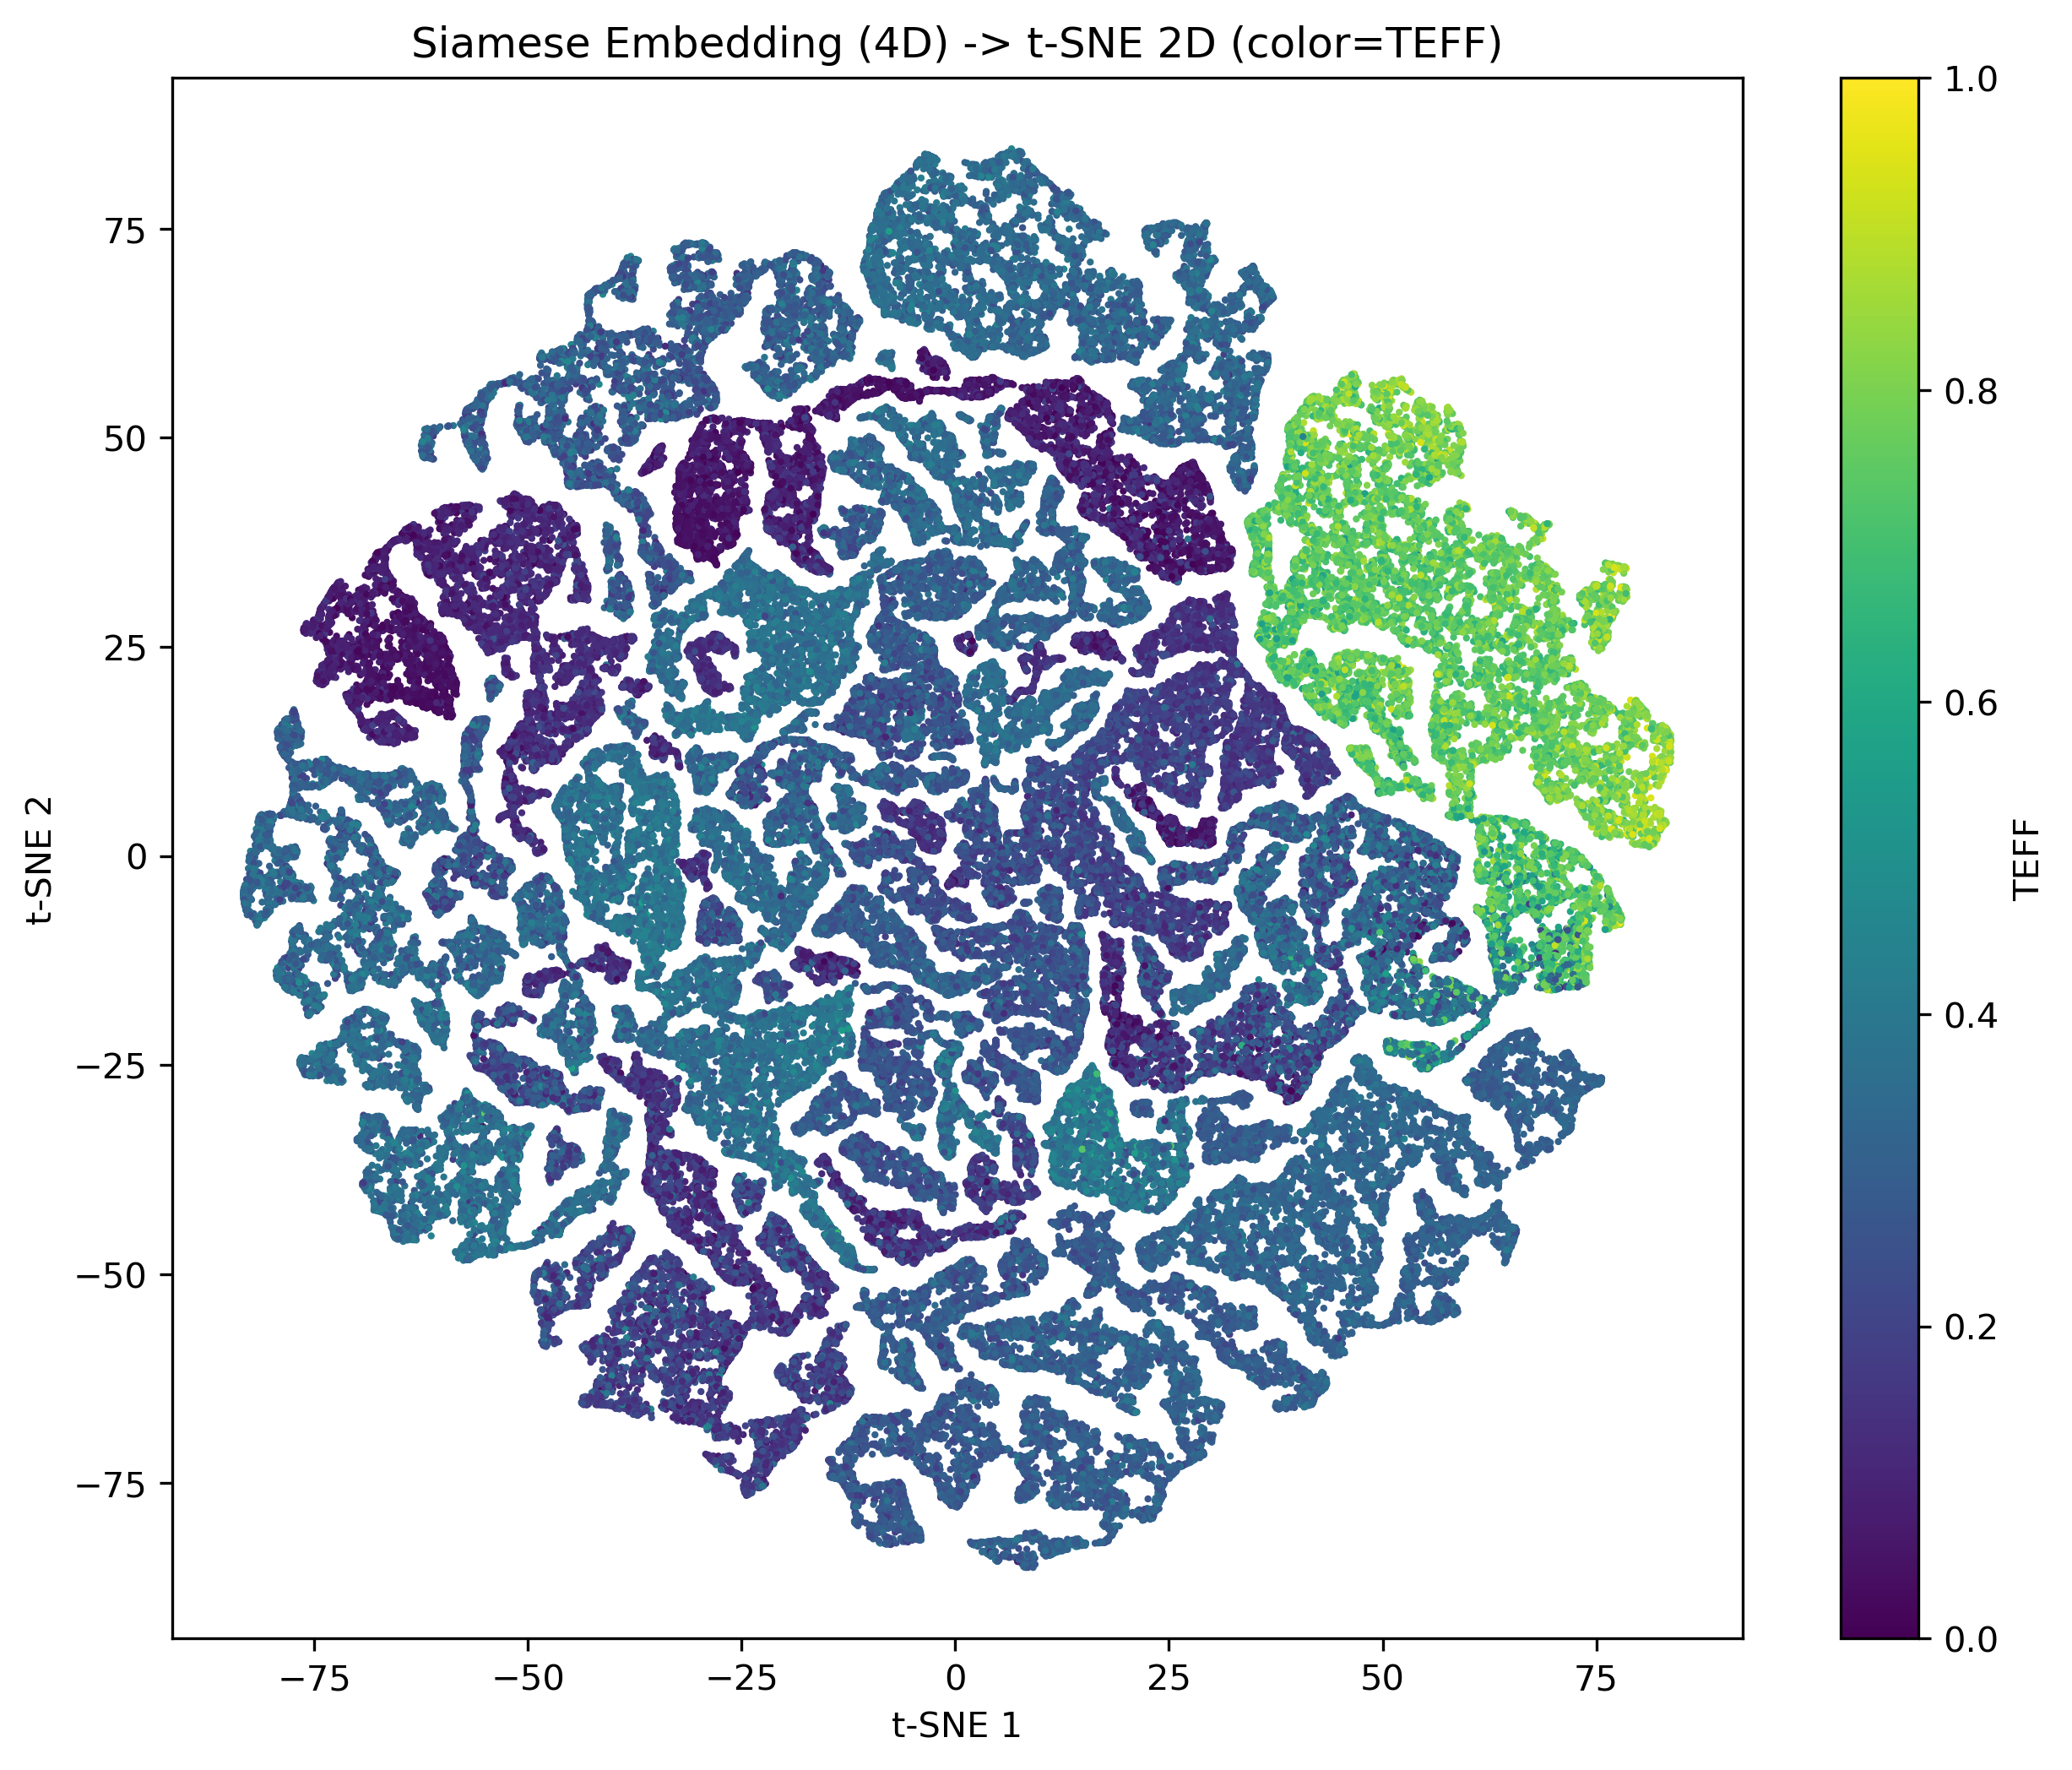

In [25]:
# Suppose we want the original TEFF from train+test concatenated
teff_all = torch.cat((y_teff_train, y_teff_test), dim=0).cpu().numpy()
logg_all = torch.cat((y_logg_train, y_logg_test), dim=0).cpu().numpy()
j_all = torch.cat((y_j_train, y_j_test), dim=0).cpu().numpy()
k_band = torch.cat((y_k_train, y_k_test), dim=0).cpu().numpy()
h_band = torch.cat((y_h_train, y_h_test), dim=0).cpu().numpy()

fig, ax = plt.subplots(figsize=(10,8), dpi=300)
sc = ax.scatter(z_2d_df["dim1"], z_2d_df["dim2"],
                c=teff_all, s=1.0, cmap='viridis')
plt.colorbar(sc, label="TEFF")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Siamese Embedding (4D) -> t-SNE 2D (color=TEFF)")
plt.show()


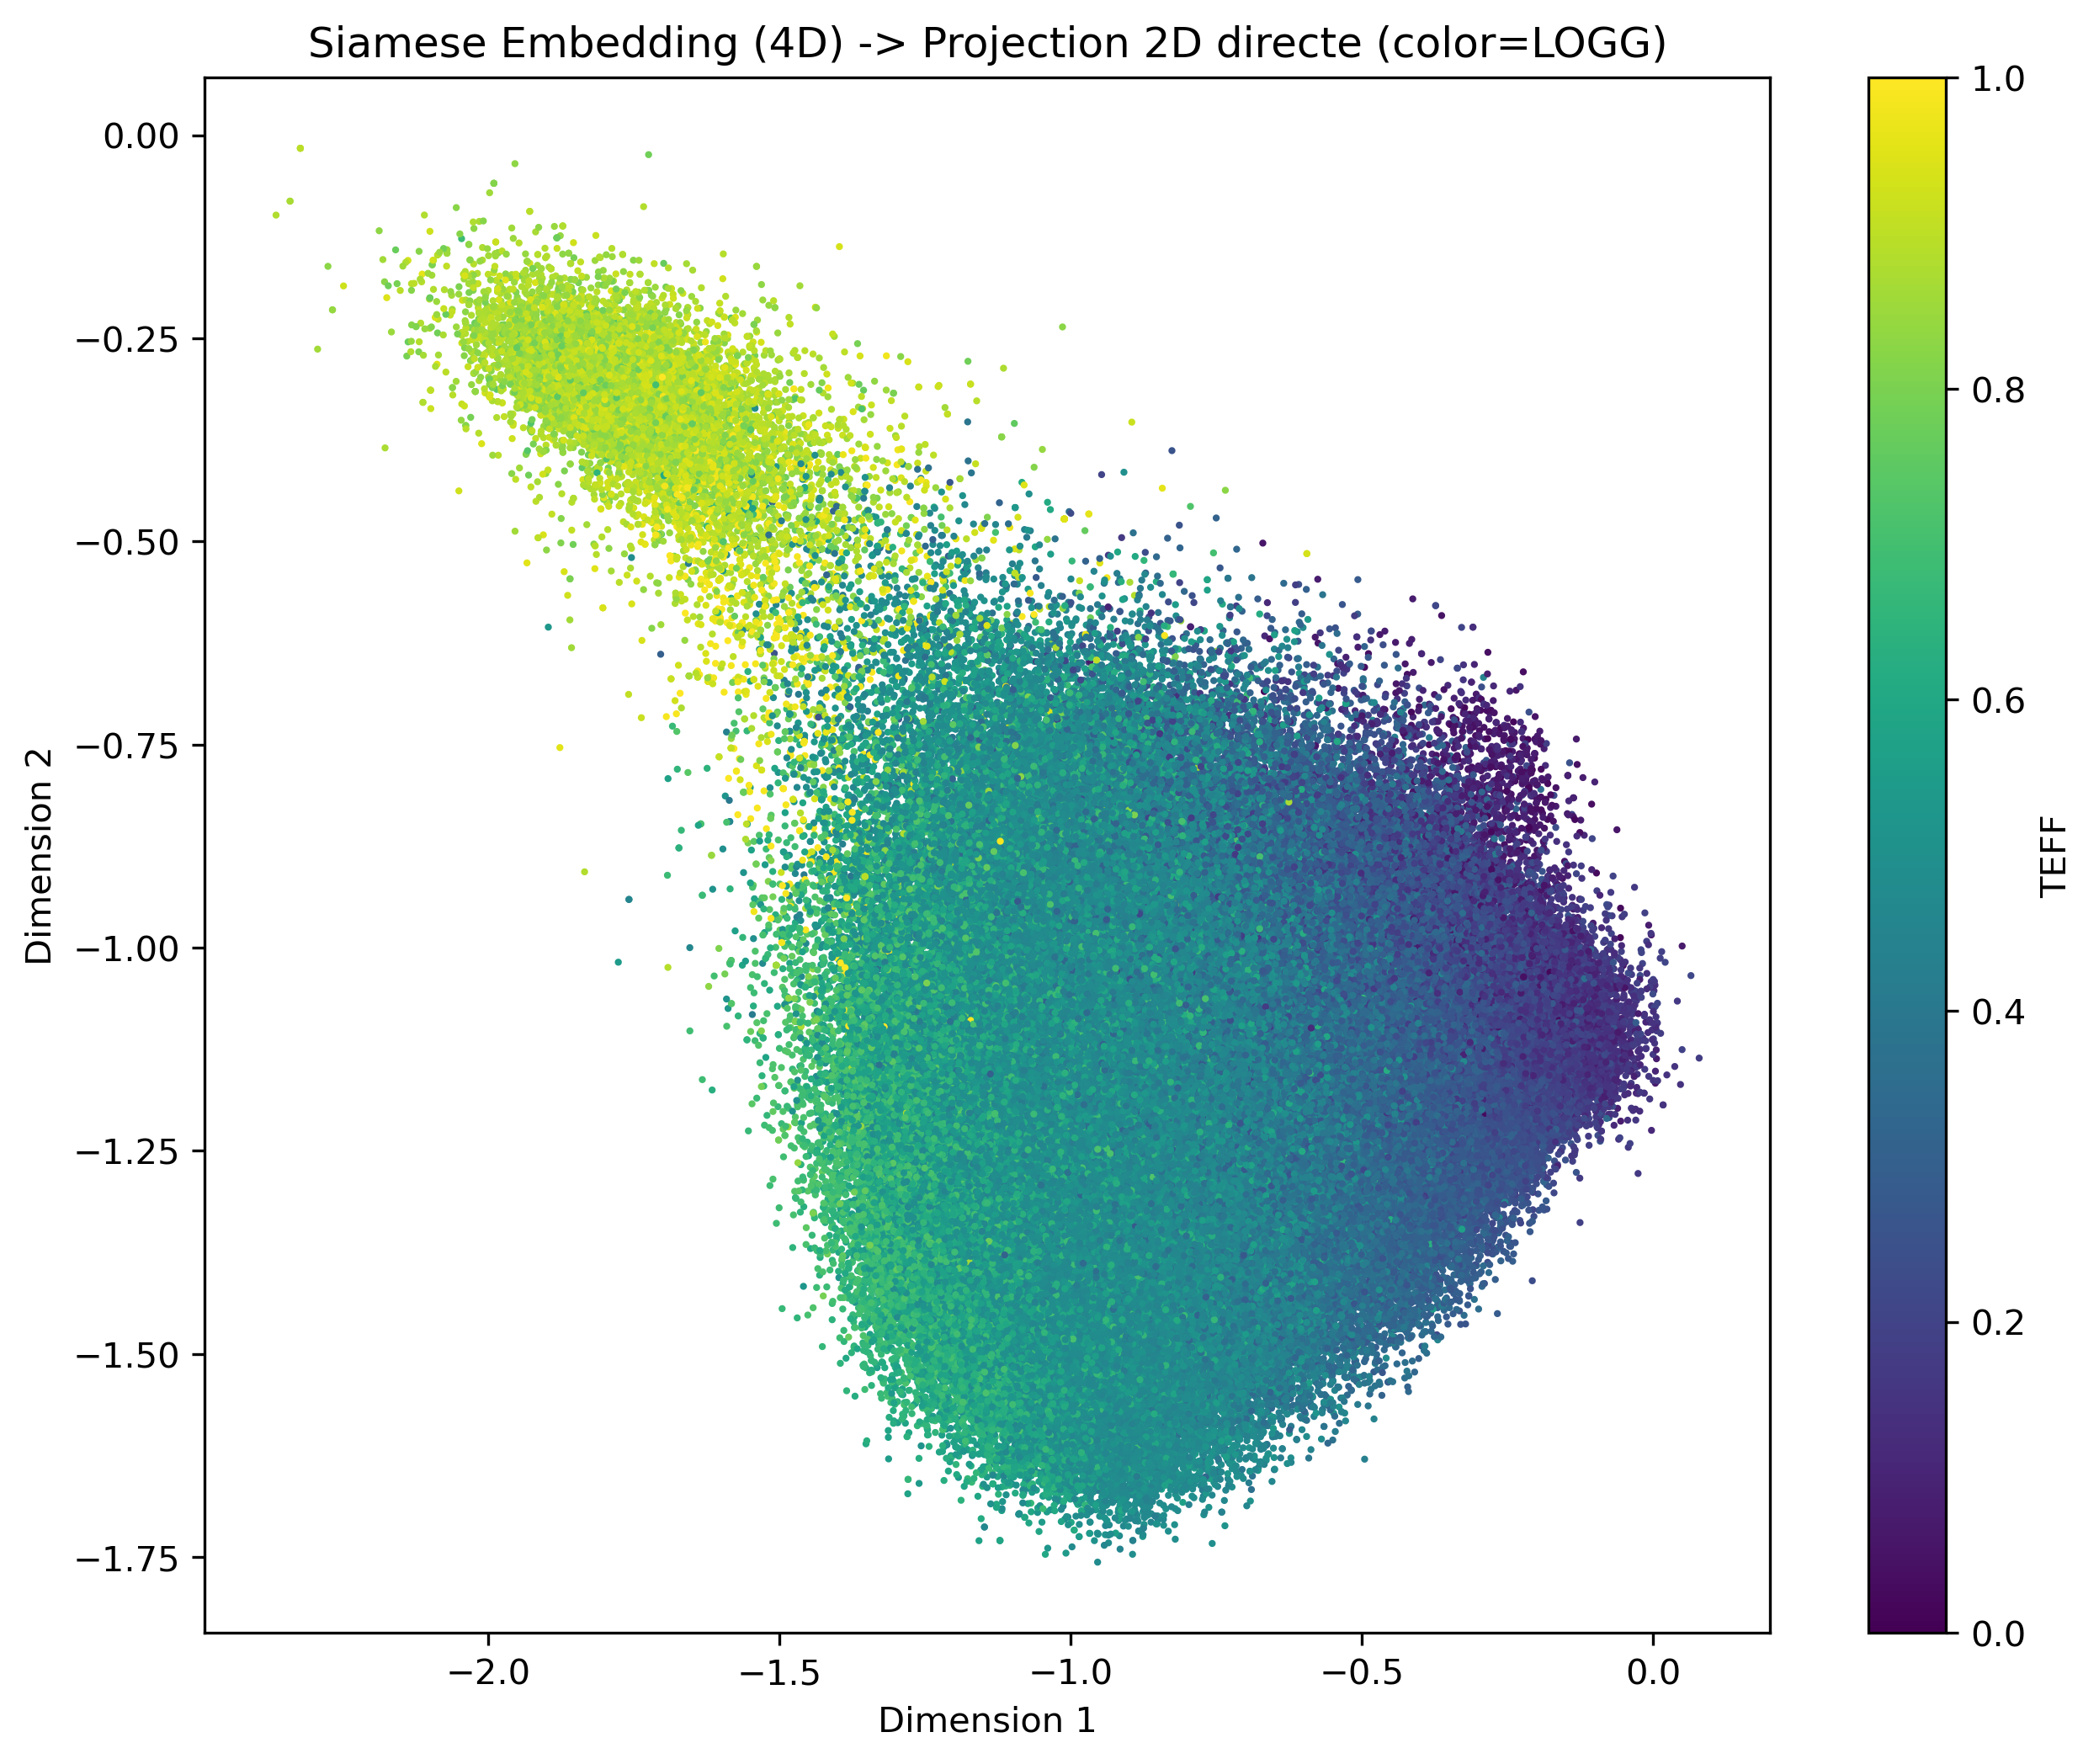

In [31]:
model.eval()
with torch.no_grad():
    # On concatène les données train et test et on les déplace sur le GPU
    X_all = torch.cat((X_train, X_test), dim=0).cuda()
    z_all, out_all = model.forward_once(X_all)  # z_all: [N, 4]

# Projection directe en 2D en sélectionnant les deux premières dimensions
z_2d_direct = z_all[:, :2].cpu().numpy()  # shape [N,2]

# Création d'un DataFrame pour faciliter le plotting (optionnel)
z_2d_df = pd.DataFrame(z_2d_direct, columns=["dim1", "dim2"])

# Concaténation des cibles TEFF (train+test)
teff_all = torch.cat((y_teff_train, y_teff_test), dim=0).cpu().numpy()
logg_all = torch.cat((y_logg_train, y_logg_test), dim=0).cpu().numpy()

# Plot
fig, ax = plt.subplots(figsize=(10,8), dpi=300)
sc = ax.scatter(z_2d_df["dim1"], z_2d_df["dim2"],
                c=logg_all, s=1.0, cmap='viridis')
plt.colorbar(sc, label="TEFF")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title("Siamese Embedding (4D) -> Projection 2D directe (color=LOGG)")
plt.show()
